C:\Users\freef\AppData\Local\Temp\ipykernel_8012\3314161773.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='Persentase_NCD', y='Negara', palette='viridis')


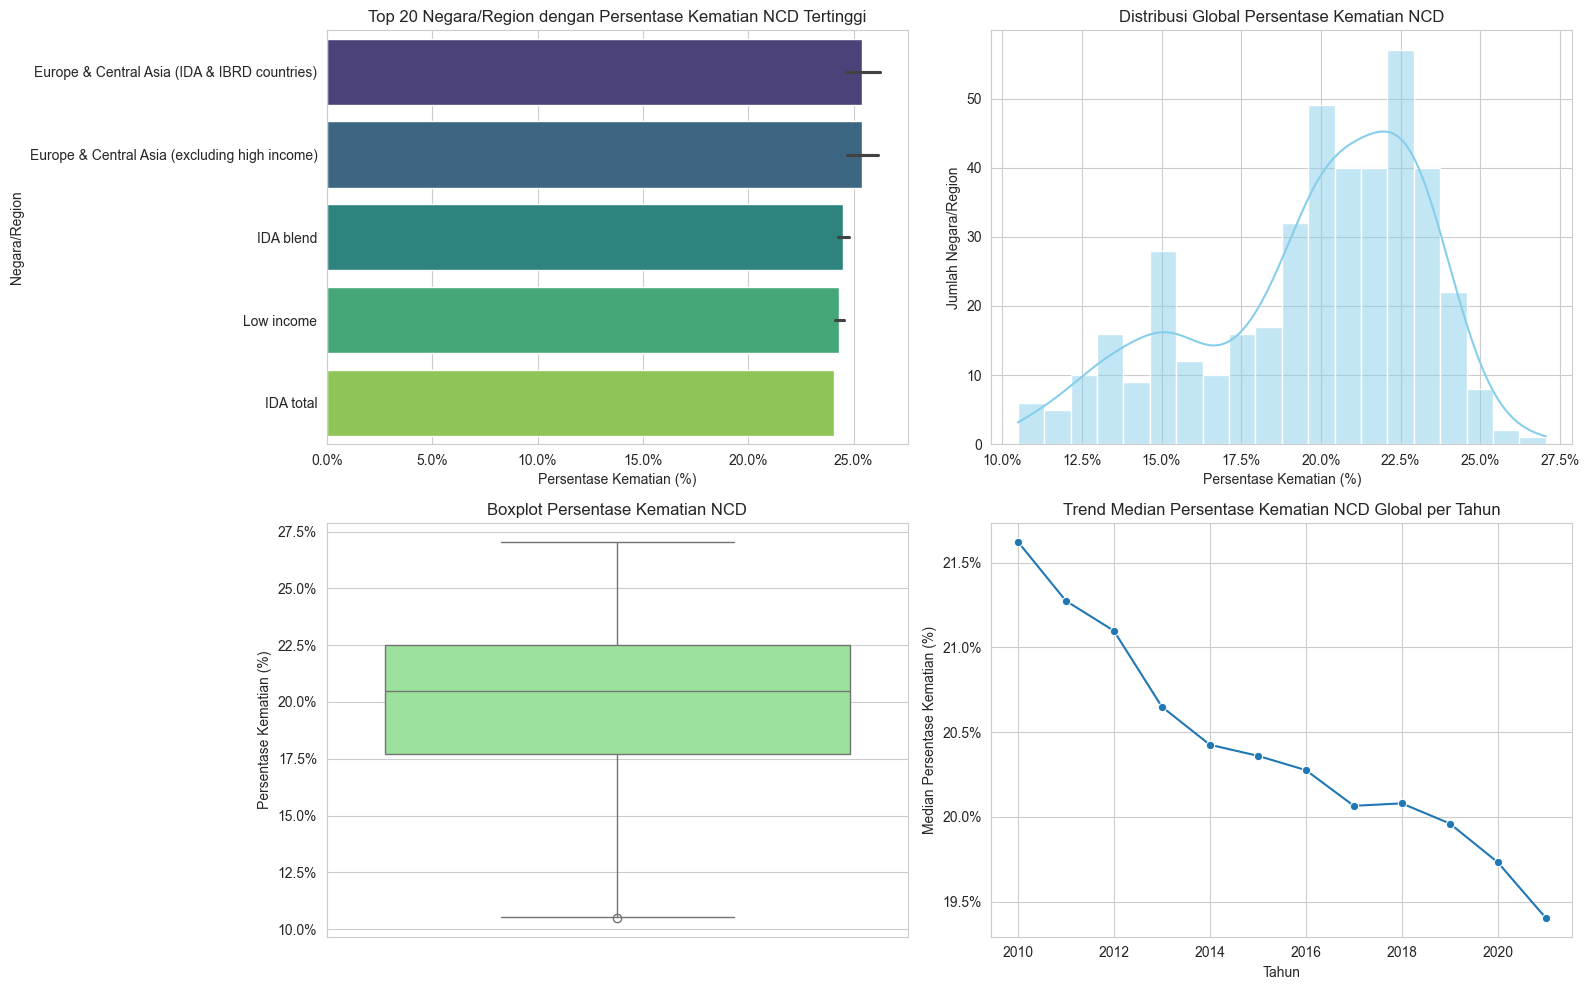

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import ast

# 1. Load data dari global_ncd_deaths.csv
df = pd.read_csv('global_ncd_deaths.csv')

# 2. Bersihkan kolom 'Negara' agar hanya nama negara/region saja
def extract_country_name(val):
    try:
        d = ast.literal_eval(val)
        return d['value']
    except Exception:
        return val

df['Negara'] = df['Negara'].apply(extract_country_name)

# 3. Ganti nama kolom agar konsisten
df = df.rename(columns={'Persentase Kematian NCD': 'Persentase_NCD', 'Tahun': 'Tahun'})

# 4. Urutkan berdasarkan persentase tertinggi
df = df.sort_values('Persentase_NCD', ascending=False)

# 5. Visualisasi
plt.figure(figsize=(16, 10))
sns.set_style("whitegrid")

# Plot 1: Top 20 Negara/Region dengan Kematian NCD Tertinggi
plt.subplot(2, 2, 1)
top_n = 20
top_countries = df.head(top_n)
sns.barplot(data=top_countries, x='Persentase_NCD', y='Negara', palette='viridis')
plt.title(f'Top {top_n} Negara/Region dengan Persentase Kematian NCD Tertinggi')
plt.xlabel('Persentase Kematian (%)')
plt.ylabel('Negara/Region')
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals=1))

# Plot 2: Histogram Distribusi Persentase Kematian NCD
plt.subplot(2, 2, 2)
sns.histplot(df['Persentase_NCD'], bins=20, kde=True, color='skyblue')
plt.title('Distribusi Global Persentase Kematian NCD')
plt.xlabel('Persentase Kematian (%)')
plt.ylabel('Jumlah Negara/Region')
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals=1))

# Plot 3: Boxplot Persentase Kematian NCD
plt.subplot(2, 2, 3)
sns.boxplot(y=df['Persentase_NCD'], color='lightgreen')
plt.title('Boxplot Persentase Kematian NCD')
plt.ylabel('Persentase Kematian (%)')
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=1))

# Plot 4: Trend Median Global per Tahun (jika ada data multi-tahun)
plt.subplot(2, 2, 4)
if df['Tahun'].nunique() > 1:
    median_per_year = df.groupby('Tahun')['Persentase_NCD'].median().reset_index()
    sns.lineplot(data=median_per_year, x='Tahun', y='Persentase_NCD', marker='o')
    plt.title('Trend Median Persentase Kematian NCD Global per Tahun')
    plt.ylabel('Median Persentase Kematian (%)')
    plt.xlabel('Tahun')
    plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=1))
else:
    plt.text(0.5, 0.5, 'Data hanya untuk satu tahun', ha='center', va='center')
    plt.axis('off')

plt.tight_layout()
plt.show()